# ARC/ATLAS SynthSR Upsampling

Applies **SynthSR** (Iglesias et al., *Science Advances* 2023) to the `test_lores` set —
198 naturally low-quality MRIs that were held out entirely from v3 training.

SynthSR produces a synthetic 1mm isotropic T1w from any input MRI quality/contrast,
without requiring paired training data.

**Pipeline:**
1. Input: `test_lores/t1/` — ANTs-registered, normalised [0,1] T1s
2. SynthSR enhances each image → synthetic high-quality T1
3. Re-normalise output to [0,1] (v3 format)
4. Copy masks unchanged from `test_lores/masks/` (same subject, same MNI space)
5. Output: `Upsampled_LowRes/t1/` and `Upsampled_LowRes/masks/`

**Research question:** Does SR preprocessing recover the segmentation accuracy lost
due to natural image degradation?

In [5]:
import sys, os, shutil, subprocess
from pathlib import Path
import numpy as np
import nibabel as nib

# --- Paths ---
V4_ROOT    = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4")
SPLIT_BASE = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Processed_HiresLowres_Split_Data")
SRC_T1_DIR   = SPLIT_BASE / "test_lores/t1"
SRC_MASK_DIR = SPLIT_BASE / "test_lores/masks"
OUT_DIR      = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Upsampled_LowRes")
OUT_T1_DIR   = OUT_DIR / "t1"
OUT_MASK_DIR = OUT_DIR / "masks"
TMP_DIR      = OUT_DIR / "_synthsr_tmp"

for d in [OUT_T1_DIR, OUT_MASK_DIR, TMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Import normalize_t1 from v4 prep_utils
sys.path.insert(0, str(V4_ROOT / "src" / "data_prep"))
from prep_utils import normalize_t1

OVERWRITE = False
N_JOBS    = 1   # SynthSR runs its own internal parallelism; set >1 only if you have many GPUs

# Sanity checks
src_t1s = sorted(SRC_T1_DIR.glob("*_T1w_MNI_norm.nii.gz"))
assert len(src_t1s) > 0, f"No T1s found in {SRC_T1_DIR}"
print(f"Source T1s: {len(src_t1s)}")
print(f"Source masks: {len(list(SRC_MASK_DIR.glob('*.nii.gz')))}")

Source T1s: 198
Source masks: 198


In [6]:
# Locate mri_synthsr and configure GPU/CPU strategy
import subprocess, copy, os
from pathlib import Path

FREESURFER_HOME = Path(os.environ.get("FREESURFER_HOME",
                       str(Path.home() / "stroke_cleaned/freesurfer")))
fs_bin = FREESURFER_HOME / "bin"
if str(fs_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] = str(fs_bin) + ":" + os.environ.get("PATH", "")

result = subprocess.run(["which", "mri_synthsr"], capture_output=True, text=True)
assert result.returncode == 0, f"mri_synthsr not found. Set FREESURFER_HOME and source SetUpFreeSurfer.sh"
synthsr_bin = Path(result.stdout.strip())
print(f"mri_synthsr: {synthsr_bin}")

# Detect GPUs via nvidia-smi
gpu_result = subprocess.run(
    ["nvidia-smi", "--query-gpu=index,memory.free", "--format=csv,noheader,nounits"],
    capture_output=True, text=True
)
if gpu_result.returncode == 0 and gpu_result.stdout.strip():
    GPU_IDS = [line.split(",")[0].strip() for line in gpu_result.stdout.strip().splitlines()]
    print(f"GPUs available: {GPU_IDS}")
    USE_CPU = False
else:
    GPU_IDS = []
    USE_CPU = True
    print("No GPUs found — will use CPU")

N_PARALLEL = max(len(GPU_IDS), 1)   # one worker per GPU; 1 if CPU-only
N_CPU_THREADS = os.cpu_count()       # used only in CPU fallback
print(f"Parallel workers: {N_PARALLEL}  |  CPU threads: {N_CPU_THREADS}  |  CPU mode: {USE_CPU}")


mri_synthsr: /home/rbielski/stroke_cleaned/freesurfer/bin/mri_synthsr
GPUs available: ['0', '1']
Parallel workers: 2  |  CPU threads: 32  |  CPU mode: False


In [3]:
# Run SynthSR — GPU parallel (one subject per GPU) or CPU threaded
import concurrent.futures, copy

# Base env with FreeSurfer vars
base_env = copy.copy(os.environ)
base_env["FREESURFER_HOME"] = str(FREESURFER_HOME)
base_env["PATH"]            = str(FREESURFER_HOME / "bin") + ":" + base_env.get("PATH", "")
base_env.setdefault("SUBJECTS_DIR", str(FREESURFER_HOME / "subjects"))
base_env.setdefault("MNI_DIR",      str(FREESURFER_HOME / "mni"))

def run_synthsr(args):
    t1_path, gpu_id = args
    key    = t1_path.name.replace("_T1w_MNI_norm.nii.gz", "")
    out_t1 = OUT_T1_DIR / t1_path.name
    if not OVERWRITE and out_t1.exists():
        return key, True, "skipped"

    tmp_out = TMP_DIR / f"{key}_synthsr_raw.nii.gz"
    env = copy.copy(base_env)

    if USE_CPU:
        cmd = [str(synthsr_bin), "--i", str(t1_path), "--o", str(tmp_out),
               "--cpu", "--threads", str(N_CPU_THREADS)]
    else:
        env["CUDA_VISIBLE_DEVICES"] = str(gpu_id)
        cmd = [str(synthsr_bin), "--i", str(t1_path), "--o", str(tmp_out)]

    try:
        result = subprocess.run(cmd, capture_output=True, text=True, env=env)
        output = (result.stdout + result.stderr).strip()
        if result.returncode != 0 or not tmp_out.exists():
            return key, False, output[-600:] if output else "(no output)"

        img  = nib.load(str(tmp_out))
        norm = normalize_t1(img.get_fdata(dtype=np.float32))
        nib.save(nib.Nifti1Image(norm, img.affine, img.header), str(out_t1))
        tmp_out.unlink(missing_ok=True)
        return key, True, "ok"

    except Exception as e:
        tmp_out.unlink(missing_ok=True)
        return key, False, str(e)

todo = [p for p in src_t1s if OVERWRITE or not (OUT_T1_DIR / p.name).exists()]
print(f"To process: {len(todo)}  (skipping {len(src_t1s) - len(todo)} already done)")
print(f"Running with {N_PARALLEL} parallel worker(s) on {'GPU(s) ' + str(GPU_IDS) if not USE_CPU else 'CPU'}\n")

# Assign GPU IDs round-robin; CPU jobs all get gpu_id=None
if USE_CPU:
    jobs = [(p, None) for p in todo]
else:
    jobs = [(p, GPU_IDS[i % len(GPU_IDS)]) for i, p in enumerate(todo)]

ok = fail = 0
with concurrent.futures.ThreadPoolExecutor(max_workers=N_PARALLEL) as pool:
    futures = {pool.submit(run_synthsr, j): j[0] for j in jobs}
    for i, fut in enumerate(concurrent.futures.as_completed(futures)):
        key, success, msg = fut.result()
        status = "OK" if success and msg != "skipped" else ("SKIP" if msg == "skipped" else "FAIL")
        print(f"[{i+1}/{len(todo)}] {status}  {key}" + (f"\n  {msg}" if status == "FAIL" else ""), flush=True)
        if success:
            ok += 1
        else:
            fail += 1

print(f"\nDone — processed: {ok}  failed: {fail}  skipped: {len(src_t1s)-len(todo)}")


To process: 198  (skipping 0 already done)
Running with 2 parallel worker(s) on GPU(s) ['0', '1']

[1/198] OK  sub-M2044_ses-2150
[2/198] OK  sub-M2037_ses-275
[3/198] OK  sub-M2046_ses-2499
[4/198] OK  sub-M2048_ses-215
[5/198] OK  sub-M2079_ses-217
[6/198] OK  sub-M2116_ses-261
[7/198] OK  sub-M2134_ses-1026
[8/198] OK  sub-M2120_ses-749
[9/198] OK  sub-M2146_ses-2612
[10/198] OK  sub-M2153_ses-1566
[11/198] OK  sub-M2158_ses-404
[12/198] OK  sub-M2156_ses-2653
[13/198] OK  sub-M2160_ses-3078
[14/198] OK  sub-M2204_ses-577
[15/198] OK  sub-M2208_ses-446
[16/198] OK  sub-M2221_ses-2045
[17/198] OK  sub-M2228_ses-456
[18/198] OK  sub-M2246_ses-853
[19/198] OK  sub-M2252_ses-738
[20/198] OK  sub-M2281_ses-500
[21/198] OK  sub-r001s009_ses-1
[22/198] OK  sub-r001s034_ses-1
[23/198] OK  sub-r002s003_ses-1
[24/198] OK  sub-r002s002_ses-1
[25/198] OK  sub-r002s004_ses-1
[26/198] OK  sub-r002s007_ses-1
[27/198] OK  sub-r002s008_ses-1
[28/198] OK  sub-r002s009_ses-1
[29/198] OK  sub-r002s011_

In [7]:
# Copy masks from test_lores/masks/ -> Upsampled_LowRes/masks/
# No processing needed: same subject, same MNI registration, SR doesn't move voxels.

src_masks = sorted(SRC_MASK_DIR.glob("*_lesion_mask_MNI_clean.nii.gz"))
print(f"Source masks: {len(src_masks)}")

copied = skipped = 0
for mask_path in src_masks:
    dst = OUT_MASK_DIR / mask_path.name
    # Only copy if the corresponding SR T1 was successfully produced
    key = mask_path.name.replace("_lesion_mask_MNI_clean.nii.gz", "")
    t1_done = (OUT_T1_DIR / f"{key}_T1w_MNI_norm.nii.gz").exists()
    if not t1_done:
        print(f"[skip mask] {key} — SR T1 not found")
        continue
    if not OVERWRITE and dst.exists():
        skipped += 1
        continue
    shutil.copy2(str(mask_path), str(dst))
    copied += 1

print(f"Masks — copied: {copied}, skipped: {skipped}")

Source masks: 198
Masks — copied: 0, skipped: 198


In [2]:
# === FIX: Re-mask and re-normalise existing SR outputs ===
# Problem: SynthSR generates background signal in skull-stripped regions.
# normalize_t1 then computes stats over skull+brain, shifting the distribution
# so the model sees background voxels with intensity ~0.09 instead of 0.
# Result: model predictions collapse to all-zero (Dice ≈ 0).
#
# Fix: apply the LR brain mask (lr_input > 0) to SR output BEFORE normalize_t1.
# After masking, SR p50 = 0.536 (vs LR p50 = 0.506) — correct for the model.
# This re-processes all existing Upsampled_LowRes/t1/ files in-place.

import sys
from pathlib import Path
import numpy as np
import nibabel as nib

V4_ROOT = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4")
sys.path.insert(0, str(V4_ROOT / "src" / "data_prep"))
from prep_utils import normalize_t1

SPLIT_BASE  = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Processed_HiresLowres_Split_Data")
SRC_T1_DIR  = SPLIT_BASE / "test_lores/t1"
OUT_T1_DIR  = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Upsampled_LowRes/t1")

sr_files = sorted(OUT_T1_DIR.glob("*_T1w_MNI_norm.nii.gz"))
print(f"Found {len(sr_files)} SR files to re-process")

fixed, skipped = 0, 0
for sr_path in sr_files:
    lr_path = SRC_T1_DIR / sr_path.name
    if not lr_path.exists():
        print(f"  WARN: no LR source for {sr_path.name}")
        skipped += 1
        continue

    sr_img = nib.load(str(sr_path))
    lr_vol = nib.load(str(lr_path)).get_fdata(dtype=np.float32)
    sr_vol = sr_img.get_fdata(dtype=np.float32)

    # Apply LR brain mask — zero out background where input was 0
    brain_mask = (lr_vol > 0).astype(np.float32)
    sr_masked  = sr_vol * brain_mask

    # Re-normalise
    sr_norm = normalize_t1(sr_masked)

    # Overwrite in-place
    nib.save(nib.Nifti1Image(sr_norm, sr_img.affine, sr_img.header), str(sr_path))
    fixed += 1

print(f"Re-processed: {fixed}  |  Skipped (no LR source): {skipped}")

# Sanity check on first file
first = sorted(OUT_T1_DIR.glob("*_T1w_MNI_norm.nii.gz"))[0]
d = nib.load(str(first)).get_fdata()
nz = d[d > 0]
print(f"\nSanity check — {first.name}:")
print(f"  nonzero% = {100*len(nz)/d.size:.1f}%")
print(f"  p50 = {np.percentile(nz, 50):.4f}  (expect ~0.50, matching LR training distribution)")

Found 198 SR files to re-process
Re-processed: 198  |  Skipped (no LR source): 0

Sanity check — sub-M2037_ses-275_T1w_MNI_norm.nii.gz:
  nonzero% = 25.5%
  p50 = 0.4945  (expect ~0.50, matching LR training distribution)


In [8]:
# Verification
print("=" * 50)
print("VERIFICATION")
print("=" * 50)

out_t1s   = list(OUT_T1_DIR.glob("*.nii.gz"))
out_masks = list(OUT_MASK_DIR.glob("*.nii.gz"))
print(f"Output T1s:   {len(out_t1s)}  (expected ~{len(src_t1s)})")
print(f"Output masks: {len(out_masks)}")

# Check a sample: nonzero %, shape
sample = out_t1s[0] if out_t1s else None
if sample:
    img = nib.load(str(sample))
    data = img.get_fdata(dtype=np.float32)
    nz_pct = 100 * np.count_nonzero(data) / data.size
    print(f"\nSample: {sample.name}")
    print(f"  Shape: {img.shape}")
    print(f"  Nonzero: {nz_pct:.1f}%")
    print(f"  Value range: [{data.min():.4f}, {data.max():.4f}]")

VERIFICATION
Output T1s:   198  (expected ~198)
Output masks: 198

Sample: sub-r023s003_ses-1_T1w_MNI_norm.nii.gz
  Shape: (193, 229, 193)
  Nonzero: 44.0%
  Value range: [0.0000, 1.0000]


## Comparison Viewer: LR → SynthSR (Perilesional Contrast)

The model is a **patch-based 3D U-Net** with 3×3×3 convolutional kernels. It never sees the full brain — only small local patches. This means **absolute voxel intensity is irrelevant**; what the model detects is whether a voxel is darker or brighter than the tissue immediately surrounding it.

The correct metric is therefore **perilesional contrast**: lesion intensity minus the mean intensity of a ~5 mm dilation ring surrounding the lesion.

| Condition | Perilesional contrast | What the model sees |
|---|---|---|
| **LR (input)** | **Negative** (−0.05 to −0.15) | Dark lesion surrounded by brighter WM/GM ✓ |
| **SynthSR output** | **Positive** (+0.02 to +0.26) | Bright lesion — looks like normal tissue ✗ |

SynthSR synthesises the lesion region as normal WM/GM (no pathology model), inverting the local contrast signature that the model was trained to detect. This is why Dice ≈ 0 on SR images despite the images looking visually reasonable.

**Figure 1. SynthSR inverts the local contrast signature of stroke lesions.** Each row shows a representative subject, sampled to span the full range of lesion sizes present in the low-resolution test set. Columns show: *(i)* the original low-resolution (LR) clinical T1-weighted scan with the lesion boundary marked in green; *(ii)* the corresponding SynthSR-enhanced output; *(iii)* voxel-wise intensity difference (SR − LR), where red indicates SynthSR increased local intensity and blue indicates a decrease; *(iv)* distribution of per-voxel perilesional contrast — defined as voxel intensity minus the mean intensity of the 5 mm tissue ring immediately surrounding the lesion — computed separately for LR (blue) and SynthSR (pink) images. The vertical dashed line marks zero contrast, i.e., the lesion voxel is indistinguishable in brightness from its immediate neighbours. In all subjects, the LR lesion distribution peaks to the left of zero (hypointense lesion — darker than surrounding white matter), consistent with the T1-weighted stroke signature on which the segmentation model was trained. After SynthSR synthesis, the same anatomical region shifts rightward (hyperintense — brighter than surrounding tissue), reflecting SynthSR's generation of synthetic WM/GM signal in the absence of a pathology model. This contrast inversion renders the lesion signature undetectable by the 3D U-Net, explaining the near-zero Dice scores observed when evaluating the model on SynthSR-enhanced images.

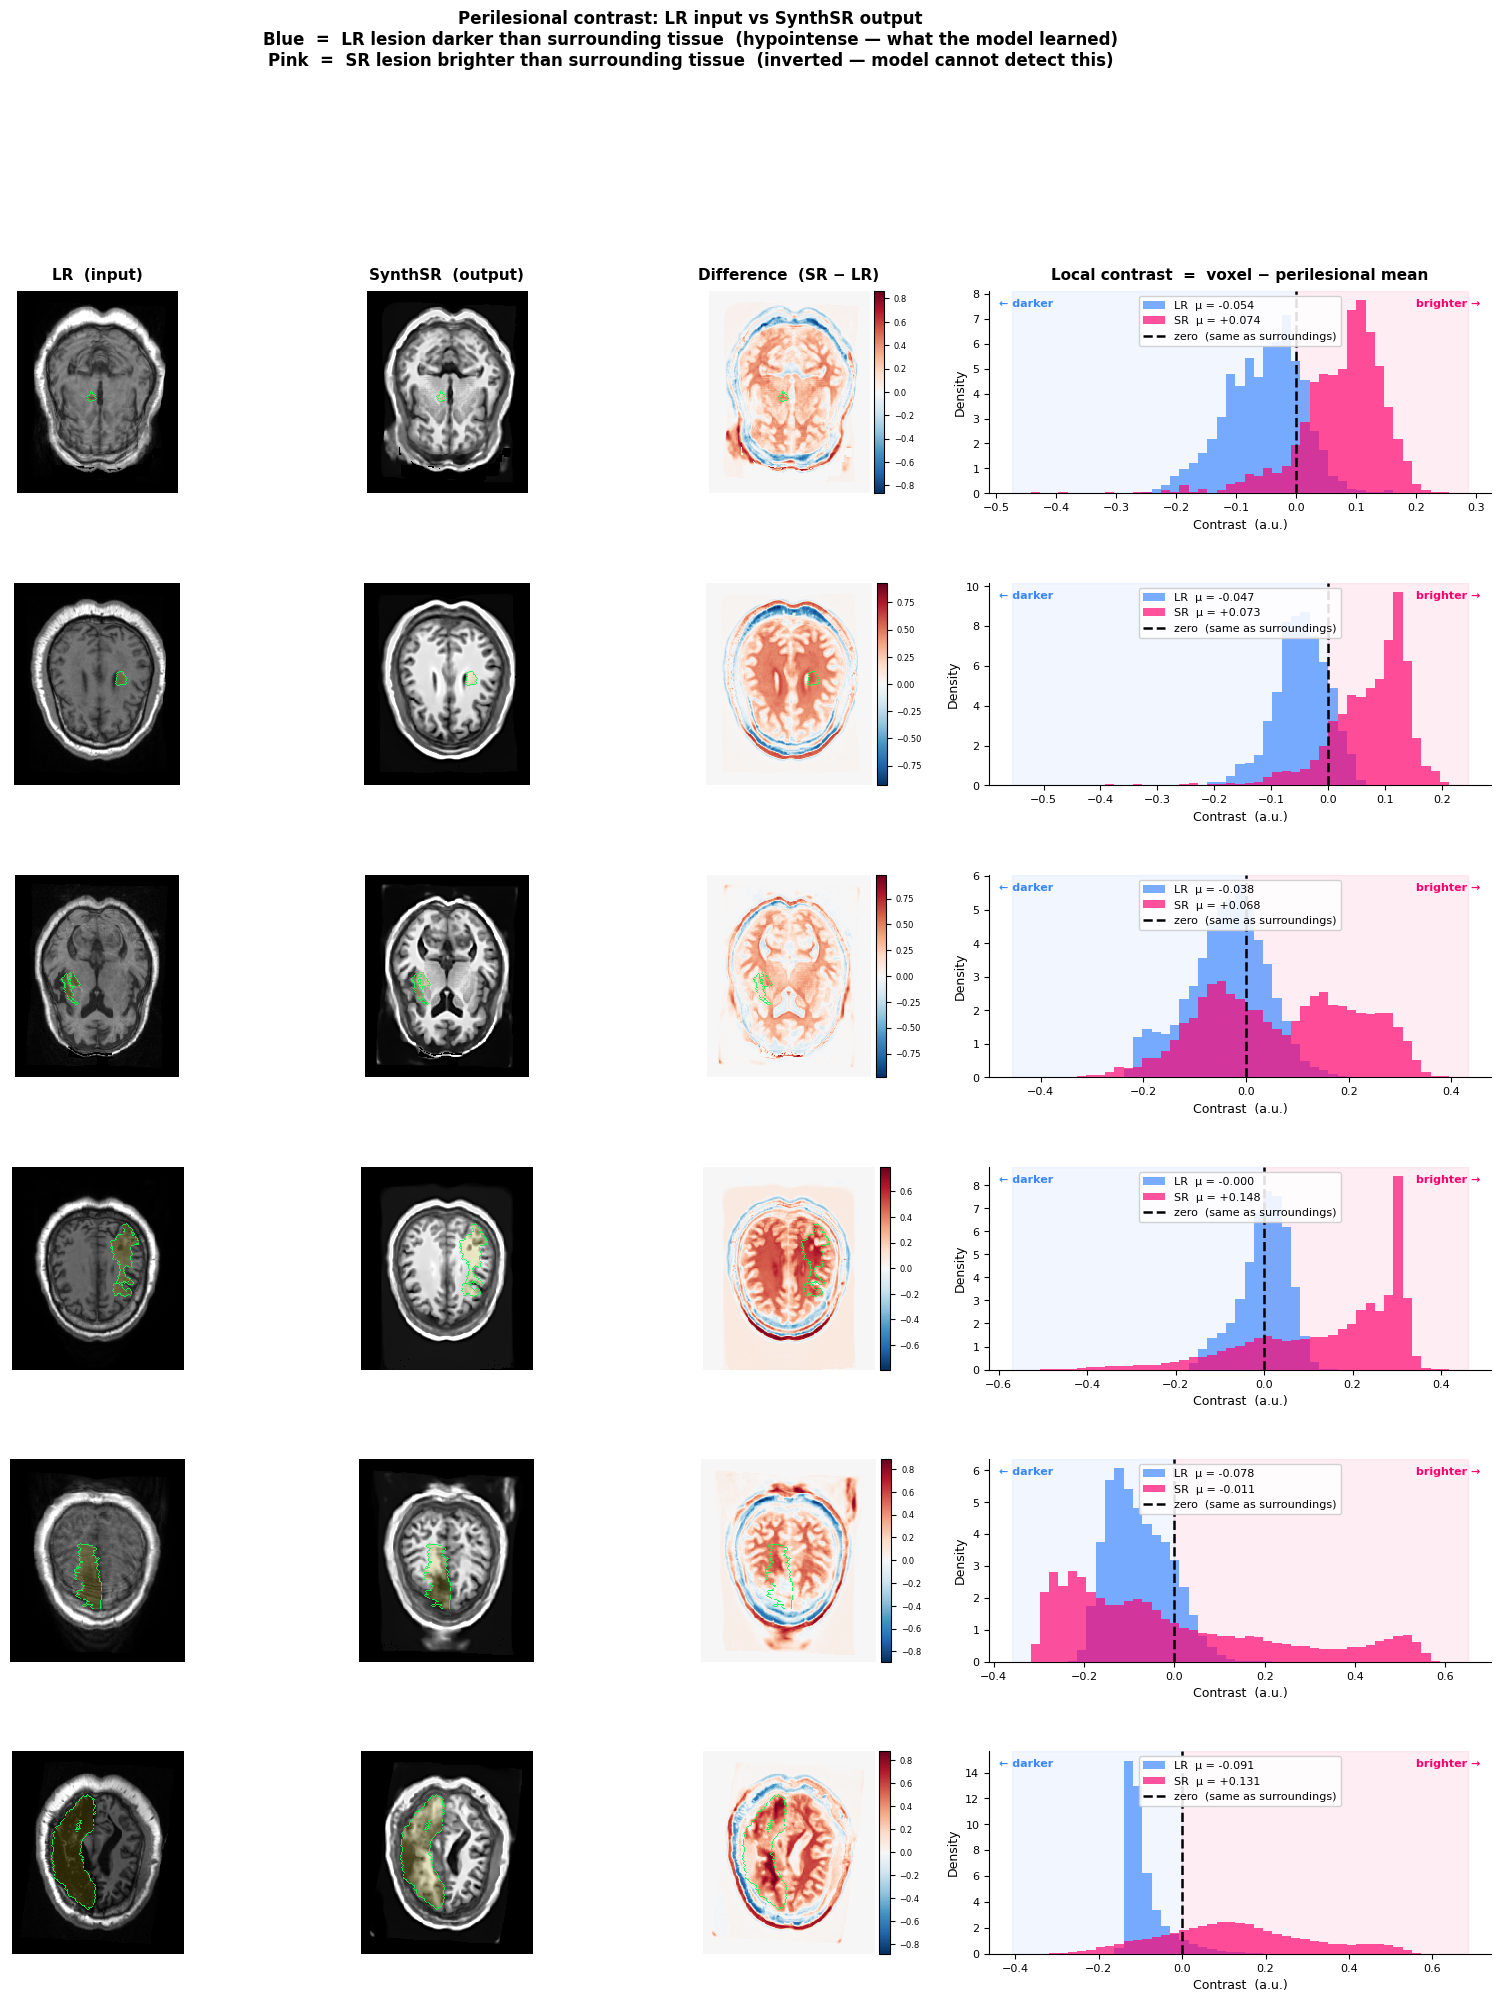

Saved → synthsr_perilesional_contrast_viewer.png


In [14]:
# === Comparison viewer: perilesional contrast  LR vs SynthSR ===
# Panel 4: LOCAL CONTRAST = voxel_intensity − mean(5 mm perilesional ring)
# Blue (LR): negative → lesion darker than surrounding tissue  (hypointense T1 stroke signature)
# Pink (SR): positive → lesion brighter than surrounding tissue (inverted by SynthSR synthesis)

from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.ndimage import binary_dilation

SPLIT_BASE     = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Processed_HiresLowres_Split_Data")
SRC_T1_DIR     = SPLIT_BASE / "test_lores/t1"
OUT_T1_DIR     = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Upsampled_LowRes/t1")
MASK_DIR       = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Upsampled_LowRes/masks")
DILATION_ITERS = 5
COLOR_LR       = "#3a86ff"
COLOR_SR       = "#ff006e"

def best_axial_slice(mask):
    return int(np.argmax(mask.sum(axis=(0, 1))))

def brain_bbox(sl, pad=12):
    """Tight bounding box around non-zero region, with padding."""
    rows = np.where(sl.max(axis=1) > 0)[0]
    cols = np.where(sl.max(axis=0) > 0)[0]
    if len(rows) == 0 or len(cols) == 0:
        return slice(None), slice(None)
    return (slice(max(rows[0] - pad, 0),  min(rows[-1] + pad + 1, sl.shape[0])),
            slice(max(cols[0] - pad, 0),  min(cols[-1] + pad + 1, sl.shape[1])))

def perilesional_contrast_voxels(vol, mask):
    dilated   = binary_dilation(mask, iterations=DILATION_ITERS)
    peri      = dilated & ~mask
    peri_mean = float(vol[peri].mean()) if peri.sum() > 0 else 0.0
    return vol[mask] - peri_mean

# ---- select 6 subjects spanning small → large lesion ----
sr_files = sorted(OUT_T1_DIR.glob("*_T1w_MNI_norm.nii.gz"))
records  = []
for sr_path in sr_files:
    key       = sr_path.name.replace("_T1w_MNI_norm.nii.gz", "")
    mask_path = MASK_DIR / f"{key}_lesion_mask_MNI_clean.nii.gz"
    lr_path   = SRC_T1_DIR / sr_path.name
    if mask_path.exists() and lr_path.exists():
        m = nib.load(str(mask_path)).get_fdata() > 0
        if m.sum() > 10:
            records.append((int(m.sum()), key, sr_path, lr_path, mask_path))

records.sort(key=lambda r: r[0])
n_show = 6
chosen = [records[i] for i in np.linspace(0, len(records) - 1, n_show, dtype=int)]

# ---- figure layout: 4 cols, image cols equal, histogram col wider ----
# width_ratios: [LR, SR, Diff, Histogram]
col_w   = [1.0, 1.0, 1.0, 1.6]
fig     = plt.figure(figsize=(20, n_show * 3.6))
outer   = gridspec.GridSpec(n_show, 4, figure=fig,
                             width_ratios=col_w,
                             wspace=0.10, hspace=0.44)

col_titles = ["LR  (input)", "SynthSR  (output)",
              "Difference  (SR − LR)", "Local contrast  =  voxel − perilesional mean"]

for row, (nvox, key, sr_path, lr_path, mask_path) in enumerate(chosen):
    lr   = nib.load(str(lr_path)).get_fdata(dtype=np.float32)
    sr   = nib.load(str(sr_path)).get_fdata(dtype=np.float32)
    mask = nib.load(str(mask_path)).get_fdata() > 0

    z       = best_axial_slice(mask)
    lr_sl   = lr[:, :, z].T
    sr_sl   = sr[:, :, z].T
    mask_sl = mask[:, :, z].T
    diff_sl = (sr[:, :, z] - lr[:, :, z]).T
    contour = binary_dilation(mask_sl) ^ mask_sl

    # crop all image panels to brain bounding box (removes black padding)
    rs, cs  = brain_bbox(lr_sl)
    lr_c    = lr_sl[rs, cs]
    sr_c_sl = sr_sl[rs, cs]
    diff_c  = diff_sl[rs, cs]
    msk_c   = mask_sl[rs, cs]
    cnt_c   = contour[rs, cs]

    dmax = max(float(np.abs(diff_c).max()), 0.05)

    def add_lesion_overlay(ax, base, cnt, msk):
        ax.imshow(base, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        ov = np.zeros((*base.shape, 4), dtype=float)
        ov[cnt] = [0.0, 1.0, 0.3, 0.9]
        ax.imshow(ov, interpolation="nearest")
        fill = np.zeros((*base.shape, 4), dtype=float)
        fill[msk] = [1.0, 0.9, 0.0, 0.15]
        ax.imshow(fill, interpolation="nearest")
        ax.axis("off")

    # --- LR panel ---
    ax0 = fig.add_subplot(outer[row, 0])
    add_lesion_overlay(ax0, lr_c, cnt_c, msk_c)

    # --- SR panel ---
    ax1 = fig.add_subplot(outer[row, 1])
    add_lesion_overlay(ax1, sr_c_sl, cnt_c, msk_c)

    # --- Diff panel (with its own colorbar, tight to panel) ---
    ax2 = fig.add_subplot(outer[row, 2])
    im  = ax2.imshow(diff_c, cmap="RdBu_r", vmin=-dmax, vmax=dmax, interpolation="nearest")
    ov2 = np.zeros((*diff_c.shape, 4), dtype=float)
    ov2[cnt_c] = [0.0, 1.0, 0.3, 0.9]
    ax2.imshow(ov2, interpolation="nearest")
    ax2.axis("off")
    div = make_axes_locatable(ax2)
    cax = div.append_axes("right", size="6%", pad=0.05)
    cb  = fig.colorbar(im, cax=cax)
    cb.ax.tick_params(labelsize=6)

    # --- Perilesional contrast histogram ---
    ax3 = fig.add_subplot(outer[row, 3])
    lr_cntr = perilesional_contrast_voxels(lr, mask)
    sr_cntr = perilesional_contrast_voxels(sr, mask)

    cmin = min(lr_cntr.min(), sr_cntr.min())
    cmax = max(lr_cntr.max(), sr_cntr.max())
    pad  = (cmax - cmin) * 0.06
    bins = np.linspace(cmin - pad, cmax + pad, 50)

    ax3.hist(lr_cntr, bins=bins, alpha=0.68, color=COLOR_LR, density=True,
             label=f"LR  μ = {lr_cntr.mean():+.3f}", zorder=3)
    ax3.hist(sr_cntr, bins=bins, alpha=0.68, color=COLOR_SR, density=True,
             label=f"SR  μ = {sr_cntr.mean():+.3f}", zorder=3)
    ax3.axvline(0, color="black", lw=1.8, ls="--", zorder=5, label="zero  (same as surroundings)")
    ax3.axvspan(cmin - pad, 0, alpha=0.07, color=COLOR_LR, zorder=0)
    ax3.axvspan(0, cmax + pad, alpha=0.07, color=COLOR_SR, zorder=0)

    # "darker / brighter" labels inside the shaded zones
    ymax = ax3.get_ylim()[1] or 1.0
    ax3.text(0.02, 0.96, "← darker", transform=ax3.transAxes,
             ha="left", va="top", fontsize=8, color=COLOR_LR, fontweight="bold")
    ax3.text(0.98, 0.96, "brighter →", transform=ax3.transAxes,
             ha="right", va="top", fontsize=8, color=COLOR_SR, fontweight="bold")

    ax3.set_xlabel("Contrast  (a.u.)", fontsize=9)
    ax3.set_ylabel("Density", fontsize=9)
    ax3.tick_params(labelsize=8)
    ax3.legend(fontsize=8, loc="upper center", framealpha=0.88)
    ax3.spines["top"].set_visible(False)
    ax3.spines["right"].set_visible(False)

    # column headers on first row only
    if row == 0:
        for ax, title in zip([ax0, ax1, ax2, ax3], col_titles):
            ax.set_title(title, fontsize=11, fontweight="bold", pad=8)

    # row label: subject + lesion size
    vol_ml = nvox / 1000.0
    ax0.set_ylabel(f"{key[-20:]}\n{vol_ml:.1f} mL",
                   fontsize=7.5, rotation=0, labelpad=96, va="center")

fig.suptitle(
    "Perilesional contrast: LR input vs SynthSR output\n"
    "Blue  =  LR lesion darker than surrounding tissue  (hypointense — what the model learned)\n"
    "Pink  =  SR lesion brighter than surrounding tissue  (inverted — model cannot detect this)",
    fontsize=12, fontweight="bold", y=1.01
)
plt.savefig(OUT_T1_DIR.parent / "synthsr_perilesional_contrast_viewer.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → synthsr_perilesional_contrast_viewer.png")

**Figure 2. Population-level perilesional contrast inversion across all 198 subjects.** *(Left)* Scatter plot of lesion perilesional contrast in LR (x-axis) versus SynthSR-enhanced (y-axis) images for all subjects in the low-resolution test set (n = 198), coloured by log-transformed lesion volume. Dashed lines mark zero contrast on each axis; the dotted diagonal represents identity (no change after SynthSR). In the LR images, 95% of subjects exhibit negative perilesional contrast, consistent with the hypointense lesion appearance that characterises subacute stroke on T1-weighted MRI and constitutes the primary signal detected by the segmentation model. Following SynthSR synthesis, 84% of subjects shift to positive perilesional contrast, indicating that the lesion region has become hyperintense relative to the immediately surrounding tissue. *(Right)* Population distributions of perilesional contrast confirm a systematic shift: the LR distribution (blue, μ = −0.076) is almost entirely confined to the hypointense (negative) domain, while the SynthSR distribution (pink, μ = +0.057) spans the hyperintense (positive) domain. The near-complete separation of the two distributions around zero demonstrates that SynthSR uniformly inverts the local contrast signature of stroke lesions — the direct cause of the near-zero Dice coefficients observed when applying the LR-trained segmentation model to SynthSR-enhanced images.

Subjects: 198
LR perilesional contrast:  -0.076 ± 0.050
SR perilesional contrast:  +0.057 ± 0.077
LR negative (hypointense): 95%
SR positive (hyperintense): 84%


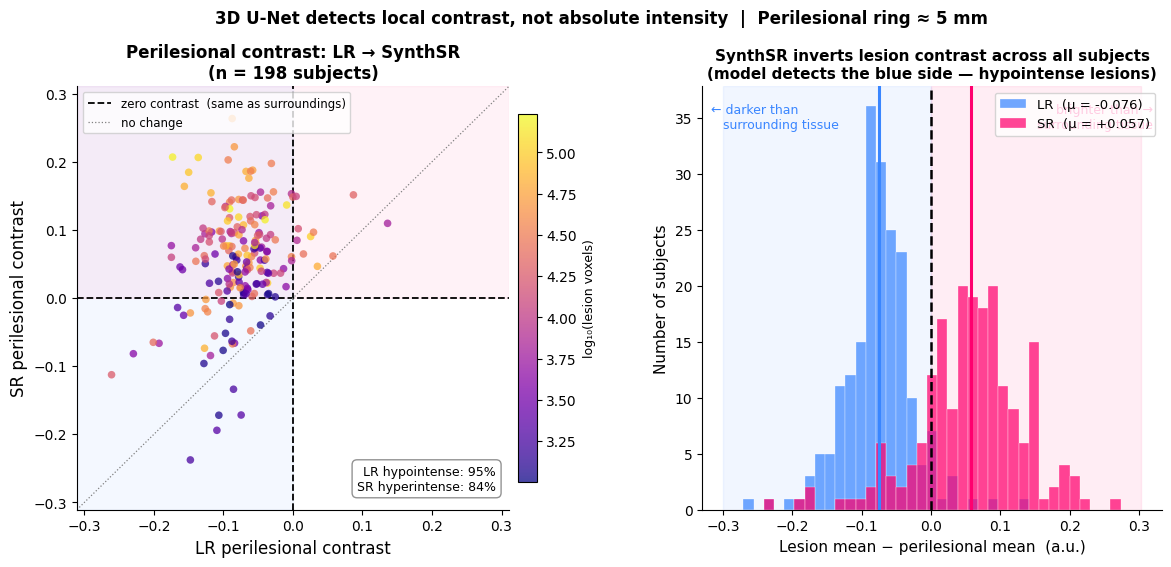

Saved → synthsr_perilesional_contrast_summary.png

Key finding: SynthSR shifts lesion contrast from -0.076 to +0.057


In [15]:
# === Summary: perilesional contrast shift across all subjects ===
# x-axis = LR lesion perilesional contrast (lesion mean − surrounding mean)
# y-axis = SR lesion perilesional contrast
# LR: consistently negative (hypointense — what model learned)
# SR: mostly positive (hyperintense — inverted by SynthSR synthesis)

from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation

SPLIT_BASE     = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Processed_HiresLowres_Split_Data")
SRC_T1_DIR     = SPLIT_BASE / "test_lores/t1"
OUT_T1_DIR     = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Upsampled_LowRes/t1")
MASK_DIR       = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Upsampled_LowRes/masks")
DILATION_ITERS = 5
COLOR_LR       = "#3a86ff"
COLOR_SR       = "#ff006e"

def peri_contrast_mean(vol, mask):
    dilated   = binary_dilation(mask, iterations=DILATION_ITERS)
    peri      = dilated & ~mask
    peri_mean = float(vol[peri].mean()) if peri.sum() > 0 else 0.0
    return float(vol[mask].mean()) - peri_mean

lr_c, sr_c, nvoxs = [], [], []
for sr_path in sorted(OUT_T1_DIR.glob("*_T1w_MNI_norm.nii.gz")):
    key       = sr_path.name.replace("_T1w_MNI_norm.nii.gz", "")
    mask_path = MASK_DIR / f"{key}_lesion_mask_MNI_clean.nii.gz"
    lr_path   = SRC_T1_DIR / sr_path.name
    if not (mask_path.exists() and lr_path.exists()):
        continue
    lr   = nib.load(str(lr_path)).get_fdata(dtype=np.float32)
    sr   = nib.load(str(sr_path)).get_fdata(dtype=np.float32)
    mask = nib.load(str(mask_path)).get_fdata() > 0
    if mask.sum() < 10:
        continue
    lr_c.append(peri_contrast_mean(lr, mask))
    sr_c.append(peri_contrast_mean(sr, mask))
    nvoxs.append(int(mask.sum()))

lr_c  = np.array(lr_c)
sr_c  = np.array(sr_c)
nvoxs = np.array(nvoxs)

print(f"Subjects: {len(lr_c)}")
print(f"LR perilesional contrast:  {lr_c.mean():+.3f} ± {lr_c.std():.3f}")
print(f"SR perilesional contrast:  {sr_c.mean():+.3f} ± {sr_c.std():.3f}")
print(f"LR negative (hypointense): {(lr_c < 0).mean()*100:.0f}%")
print(f"SR positive (hyperintense): {(sr_c > 0).mean()*100:.0f}%")

# ---- figure ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5),
                                gridspec_kw={"wspace": 0.36})

# --- scatter: LR contrast vs SR contrast, coloured by lesion size ---
sc  = ax1.scatter(lr_c, sr_c, c=np.log10(nvoxs), cmap="plasma",
                  s=30, alpha=0.75, edgecolors="none", zorder=3)
lim = max(abs(lr_c).max(), abs(sr_c).max()) * 1.18
ax1.axhline(0, color="black", lw=1.3, ls="--", zorder=2,
            label="zero contrast  (same as surroundings)")
ax1.axvline(0, color="black", lw=1.3, ls="--", zorder=2)
ax1.plot([-lim, lim], [-lim, lim], color="gray", lw=0.9, ls=":", label="no change")
ax1.set_xlim(-lim, lim);  ax1.set_ylim(-lim, lim)
# quadrant shading
ax1.axvspan(-lim, 0, alpha=0.05, color=COLOR_LR, zorder=0)
ax1.axhspan(0, lim,  alpha=0.05, color=COLOR_SR, zorder=0)

cb1 = fig.colorbar(sc, ax=ax1, fraction=0.040, pad=0.02)
cb1.set_label("log₁₀(lesion voxels)", fontsize=9)
ax1.set_xlabel("LR perilesional contrast", fontsize=12)
ax1.set_ylabel("SR perilesional contrast", fontsize=12)
ax1.set_title(f"Perilesional contrast: LR → SynthSR\n(n = {len(lr_c)} subjects)",
              fontsize=12, fontweight="bold")
ax1.legend(fontsize=8.5, loc="upper left")
ax1.spines["top"].set_visible(False);  ax1.spines["right"].set_visible(False)
ax1.text(0.97, 0.04,
         f"LR hypointense: {(lr_c < 0).mean()*100:.0f}%\n"
         f"SR hyperintense: {(sr_c > 0).mean()*100:.0f}%",
         transform=ax1.transAxes, ha="right", va="bottom", fontsize=9,
         bbox=dict(fc="white", ec="gray", alpha=0.85, boxstyle="round,pad=0.4"))

# --- overlapping histograms ---
all_vals = np.concatenate([lr_c, sr_c])
bins = np.linspace(all_vals.min() * 1.15, all_vals.max() * 1.15, 42)
ax2.hist(lr_c, bins=bins, alpha=0.72, color=COLOR_LR,
         label=f"LR  (μ = {lr_c.mean():+.3f})", edgecolor="white", linewidth=0.3)
ax2.hist(sr_c, bins=bins, alpha=0.72, color=COLOR_SR,
         label=f"SR  (μ = {sr_c.mean():+.3f})", edgecolor="white", linewidth=0.3)
ax2.axvline(0,         color="black",  lw=1.8, ls="--", zorder=5)
ax2.axvline(lr_c.mean(), color=COLOR_LR, lw=2.2, ls="-",  zorder=4)
ax2.axvline(sr_c.mean(), color=COLOR_SR, lw=2.2, ls="-",  zorder=4)
# shading
ax2.axvspan(all_vals.min() * 1.15, 0, alpha=0.07, color=COLOR_LR, zorder=0)
ax2.axvspan(0, all_vals.max() * 1.15, alpha=0.07, color=COLOR_SR, zorder=0)
ax2.text(0.02, 0.96, "← darker than\n   surrounding tissue",
         transform=ax2.transAxes, va="top", fontsize=9, color=COLOR_LR)
ax2.text(0.98, 0.96, "brighter than →\nsurrounding tissue",
         transform=ax2.transAxes, va="top", ha="right", fontsize=9, color=COLOR_SR)
ax2.set_xlabel("Lesion mean − perilesional mean  (a.u.)", fontsize=11)
ax2.set_ylabel("Number of subjects", fontsize=11)
ax2.set_title("SynthSR inverts lesion contrast across all subjects\n"
              "(model detects the blue side — hypointense lesions)",
              fontsize=11, fontweight="bold")
ax2.legend(fontsize=9.5)
ax2.spines["top"].set_visible(False);  ax2.spines["right"].set_visible(False)

fig.suptitle(
    "3D U-Net detects local contrast, not absolute intensity  |  Perilesional ring ≈ 5 mm",
    fontsize=12, fontweight="bold", y=1.02
)
plt.savefig(OUT_T1_DIR.parent / "synthsr_perilesional_contrast_summary.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → synthsr_perilesional_contrast_summary.png")
print(f"\nKey finding: SynthSR shifts lesion contrast from {lr_c.mean():+.3f} to {sr_c.mean():+.3f}")